## Image Subtraction for Transient Detection

#### Imports

In [1]:
import os
import numpy as np
import os.path as pa
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import ImageGrid
from photutils.background import Background2D, MedianBackground
from astropy.stats import SigmaClip

from scipy.ndimage import gaussian_filter


from astropy.io import fits, ascii
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.visualization import astropy_mpl_style, ZScaleInterval
from astropy.nddata import Cutout2D
import astropy.units as u
from astropy.wcs import WCS
from regions import Regions


from sfft.EasySparsePacket import Easy_SparsePacket

from sfft.utils.pyAstroMatic.PYSWarp import PY_SWarp
import time
from pathlib import Path
import glob

import photometrus.photometry.photometry as photometry
import photometrus.stack.stack as stack

import photometrus_utils as util
import sfft_util
print("Done!")


/home/alex/miniconda3/envs/photo310/lib/python3.10/site-packages/sfft/utils/HoughDetection.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Done!


#### Configuration and Alignment

In [2]:


t = time.time()
FILE_BASENAME = f"sub_test_{t}"

# * computing backend and resourse 
BACKEND_4SUBTRACT = 'Numpy'	 # FIXME {'Cupy', 'Numpy'}, Use 'Numpy' if you only have CPUs
CUDA_DEVICE_4SUBTRACT = '0'	 # FIXME ONLY work for backend Cupy
NUM_CPU_THREADS_4SUBTRACT = 10   # FIXME ONLY work for backend Numpy

# * required info in FITS header
GAIN_KEY = 'GAIN'  # not GAIN_CAL			 # NOTE Keyword of Gain in FITS header
SATUR_KEY = 'SATURATE'		  # NOTE Keyword of Saturation in FITS header

# * how to subtract
GKerHW = None				   # FIXME given matching kernel half width
KerHWRatio = 2.0				# FIXME Ratio of kernel half width to FWHM (typically, 1.5-2.5).
KerPolyOrder = 2			  # FIXME {0, 1, 2, 3}, Polynomial degree of kernel spatial variation
BGPolyOrder = 0 # trivial for sparse (already sky subtracted)			# As above but for CROWDED field
ConstPhotRatio =  False	  #False	# FIXME Constant photometric ratio between images? dont scale them
PriorBanMask = None			 # FIXME None or a boolean array with same shape of science/reference.
MatchTol = 3 # pixel difference required for source match

COARSE_VAR_REJECTION = False #True	 # FIXME Coarse Variable Rejection? {True, False}
CVREJ_MAGD_THRESH = 0.12		# FIXME magnitude threshold for Coarse Variable Rejection
ELABO_VAR_REJECTION = False #True	  # FIXME Elaborate Variable Rejection? {True, False}


FITS_SCI = '/mnt/photometry/AT2025syx/field8448-2025-07-12/J/stack/coadd.Open-J.02678702-02678738.C2.fits'
FITS_REF = '/mnt/photometry/AT2025syx/field8448-2025-12-13/J/stack/coadd.Open-J.03286750-03286786.C2.fits'

# FITS_SCI = '/mnt/photometry/AT2025aayv/field8786-2025-11-03/J/stack/coadd.Open-J.03159535-03159571.C1.fits'
# FITS_REF = '/mnt/photometry/AT2025aayv/field8786-2026-01-11/J/stack/coadd.Open-J.03362257-03362293.C1.fits'
# FITS_SCI = '/mnt/photometry/AT2025lbx/field16523-2025-06-01/J/stack/coadd.Open-J.02519569-02519605.C2.fits'
# FITS_REF = '/mnt/photometry/AT2025lbx/field16523-2026-01-12/J/stack/coadd.Open-J.03365653-03365689.C2.fits'

dir_data = os.path.dirname(os.path.dirname(os.path.dirname(os.path.dirname(FITS_SCI))))


sci_stack = os.path.dirname(FITS_SCI)
ref_stack = os.path.dirname(FITS_REF)

# FITS_SCI, FITS_REF, ra, dec = get_sci_ref(sci_stack, ref_stack)
ra, dec = sfft_util.get_ra_dec(FITS_SCI)

# align with Orion's method
FITS_SCI, FITS_REF, out_name = util.multi_epoch_astrom(FITS_SCI, FITS_REF)

FITS_DIFF = dir_data+'/'+FILE_BASENAME+'.sfftdiff.fits'			# difference
FITS_REF_al = FITS_REF[:-5] + '.aligned.fits'   # refernce aligned

# align with swarp
PY_SWarp.PS(FITS_obj=FITS_REF, FITS_ref=FITS_SCI, FITS_resamp=FITS_REF_al, \
    GAIN_KEY=GAIN_KEY, SATUR_KEY=SATUR_KEY, OVERSAMPLING=1, RESAMPLING_TYPE='LANCZOS3', \
    SUBTRACT_BACK='N', FILL_VALUE=np.nan, VERBOSE_TYPE='NORMAL', VERBOSE_LEVEL=2)

FITS_REF = FITS_REF_al

print('\nMeLOn CheckPoint: IMAGE ALIGNMENT WITH SWARP DONE!\n')
print('Ref. Image aligned: '+FITS_REF_al)
print('Diff. Image:'+FITS_DIFF)


Sextracting base epoch: coadd.Open-J.02678702-02678738.C2.fits...
Including weight map!
Sextracting matching epoch: coadd.Open-J.03286750-03286786.C2.fits...
Including weight map!


> 
----- SCAMP 2.14.0 started on 2026-09-10 at 21:44:36 with 20 threads

> 
----- 1 input:
> Examining Catalog coadd.Open-J.03286750-03286786.C2.cat
coadd.Open-J.03286750-03286786.C2.cat:  "no ident           "  no ext. header   1 set    8691 detections

----- 8691 detections loaded
> Grouping fields on the sky ...
> Grouping fields: field 1/1, 0 group
> 

----- 1 instrument found for astrometry:

Instrument A1 :
1 extension

----- 1 instrument found for photometry:

Instrument P1 :

----- 1 field group found:

 Group  1: 1 field at 23:31:38.70 -28:28:50.1 with radius 26.96'
                  instruments  epoch      center coordinates     radius   scale 
coadd.Open-J.0328675 A1  P1       0.0  23:31:38.70 -28:28:50.1   26.96'  0.4975"

> Making mosaic adjustments...
> 
----- Reference catalogs:

> Examining Catalog coadd.Open-J.02678702-02678738.C2.cat...
> Loading Catalog coadd.Open-J.02678702-02678738.C2.cat...

> WARNING: ref_epoch parameter not found in catalog coadd.Open-J.02678702

MeLOn CheckPoint: Run SWarp Command ... 
 cd /tmp/PYSWarp_lzk_jl1c && swarp /mnt/photometry/AT2025syx/field8448-2025-12-13/J/stack/coadd.Open-J.03286750-03286786.C2.fits -IMAGEOUT_NAME /tmp/PYSWarp_lzk_jl1c/coadd.Open-J.03286750-03286786.C2.tmp_resamp.fits -WEIGHTOUT_NAME /tmp/PYSWarp_lzk_jl1c/coadd.Open-J.03286750-03286786.C2.tmp_resamp_weight.fits -c /tmp/PYSWarp_lzk_jl1c/PYSWarp_jnfcqwu2swarp_config/PYSWarp.swarp


> 
----- SWarp 2.38.0 started on 2026-09-10 at 21:44:38 with 20 threads

> Examining input data ...
> Looking for coadd.Open-J.03286750-03286786.C2.fits ...

> WARNING: /mnt/photometry/AT2025syx/field8448-2025-12-13/J/stack/coadd.Open-J.03286750-03286786.C2.fits has flux scale = 0: I will take 1 instead

> Creating NEW output image ...

> WARNING: FITS header data read in /tmp/PYSWarp_lzk_jl1c/coadd.Open-J.03286750-03286786.C2.tmp_resamp.head

> Creating NEW weight-map ...
> 
------- Output File coadd.Open-J.03286750-03286786.C2.tmp_resamp.fits:
    "no ident"  WEIGHTED  EXT. HEADER  4592x4626  32 bits (floats)
    Center: 23:31:38.63 -28:28:37.3   38.1'x38.4'  Scale: 0.4975 ''/pixel
    Gain: 0 e-/ADU   Flux scaling (astrom/photom): 1 X / 1 X

> Loading input data ...
> 
-------------- File coadd.Open-J.03286750-03286786.C2.fits:
    "no ident"  unweighted  no ext. header  4579x4617  32 bits (floats)
    Center: 23:31:38.70 -28:28:50.0   38'x38.3'  Scale: 0.4975 ''/pixel
    Gain: 6.3


MeLOn CheckPoint: IMAGE ALIGNMENT WITH SWARP DONE!

Ref. Image aligned: /mnt/photometry/AT2025syx/field8448-2025-12-13/J/stack/coadd.Open-J.03286750-03286786.C2.aligned.fits
Diff. Image:/mnt/photometry/AT2025syx/sub_test_1789069461.2746172.sfftdiff.fits


#### Raw Images

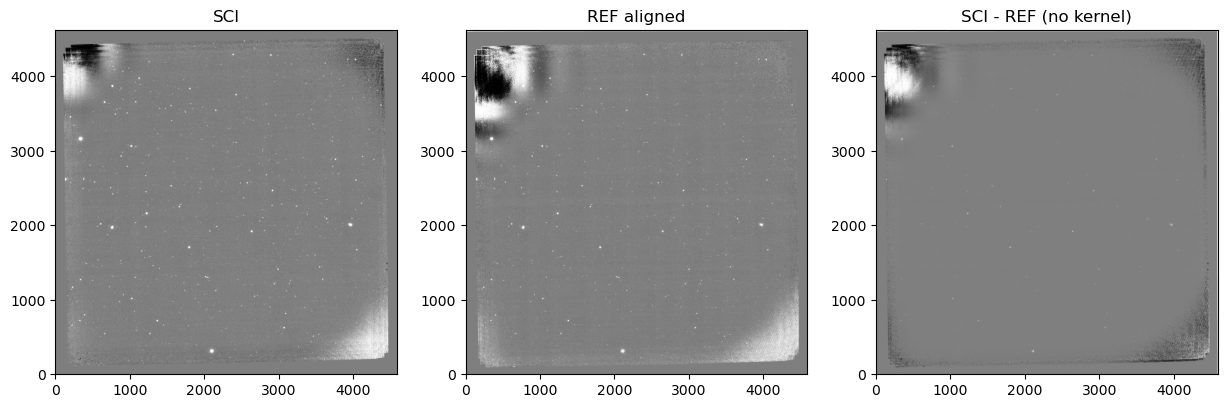

In [3]:
sci = fits.getdata(FITS_SCI)
ref = fits.getdata(FITS_REF)

interval = ZScaleInterval()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(interval(sci), origin='lower', cmap='gray')
axes[0].set_title('SCI')
axes[1].imshow(interval(ref), origin='lower', cmap='gray')
axes[1].set_title('REF aligned')

# Difference without any kernel matching - should show stars if misaligned
axes[2].imshow(sci - ref, origin='lower', cmap='gray', vmin=-100, vmax=100)
axes[2].set_title('SCI - REF (no kernel)')
plt.show()

#### Masked Images

sky_level: 2.1240128e-05
sky_level: 0.0
sky_level: -6.248122e-06
sky_level: 0.0


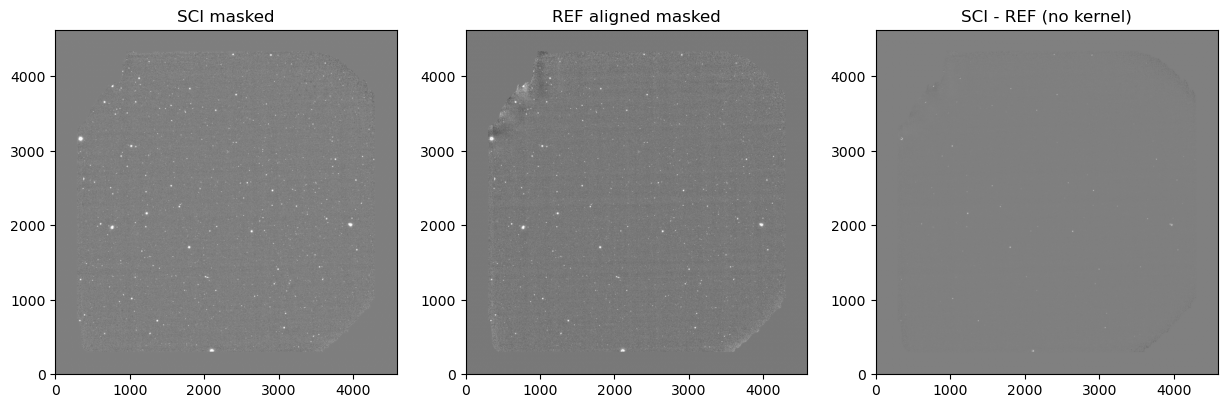

0.0
[]
made cutout:  /mnt/photometry/GRB_diff_raw_Cutout.png


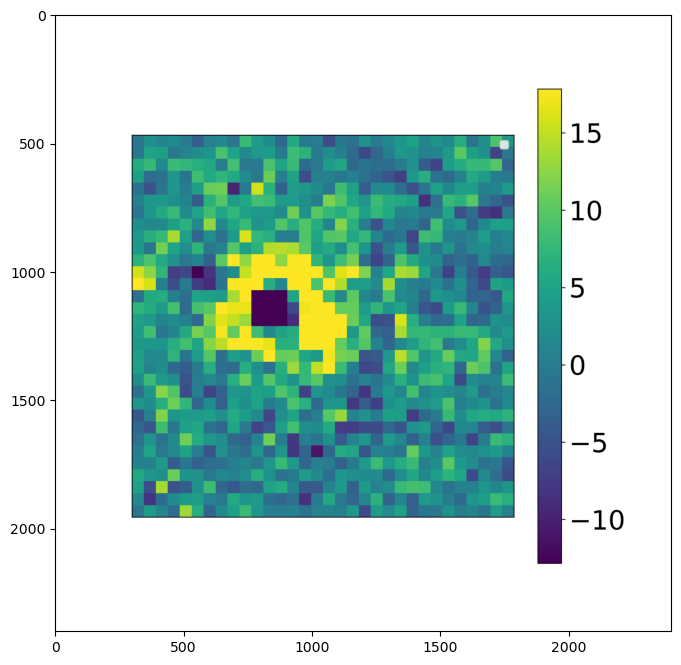

('GRB_diff_raw_Cutout', 'GRB_diff_raw_query_thresh.reg')

In [4]:
def rms_mask(image_path):
    data = fits.getdata(image_path)
    sigma_clip = SigmaClip(sigma=3)
    bkg = Background2D(data, box_size=64, filter_size=3,
                       sigma_clip=sigma_clip,
                       bkg_estimator=MedianBackground())
    
    rms = bkg.background_rms
    rms_smooth = gaussian_filter(rms, sigma=20)  # tune sigma to taste
    
    bad = (rms > 2.5 * np.median(rms)) | ~np.isfinite(data)
    
    return bad, bkg.background


def mask(image_path, rms_mask_1, rms_mask_2, bkg):
    data = fits.getdata(image_path)
    
    # Mask bad regions (e.g. corners where rms is elevated)
    bad = rms_mask_1 | rms_mask_2  
    data_clean = data.copy()
    data_clean -=bkg
    sky_level = np.nanmedian(data_clean)
    print('sky_level:', sky_level)
    
    crop = 300
    data_clean[:crop, :] = sky_level      
    data_clean[-crop:, :] = sky_level     
    data_clean[:, :crop] = sky_level     
    data_clean[:, -crop:] = sky_level    
    data_clean[bad] = sky_level 
    
    sky_level = np.nanmedian(data_clean)

    
    sky_level = np.nanmedian(data_clean)
    data_clean -= sky_level # subtract background level to even out images
    
    sky_level = np.nanmedian(data_clean)
    print('sky_level:', sky_level)
    
    
    outname = image_path[:-5]+'_masked.fits'
    fits.writeto(outname, data_clean, header=fits.getheader(image_path), overwrite=True)
    return outname

rms_mask_sci, bkg_sci = rms_mask(FITS_SCI)
rms_mask_ref, bkg_ref = rms_mask(FITS_REF_al)
 
FITS_mSCI = mask(FITS_SCI, rms_mask_sci, rms_mask_ref, bkg_sci)
FITS_mREF = mask(FITS_REF_al, rms_mask_sci, rms_mask_ref, bkg_ref)


sci = fits.getdata(FITS_mSCI)
ref = fits.getdata(FITS_mREF)

interval = ZScaleInterval()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(interval(sci), origin='lower', cmap='gray')
axes[0].set_title('SCI masked')
axes[1].imshow(interval(ref), origin='lower', cmap='gray')
axes[1].set_title('REF aligned masked')

# Difference without any kernel matching - should show stars if misaligned

axes[2].imshow(sci - ref, origin='lower', cmap='gray', vmin=-100, vmax=100)
axes[2].set_title('SCI - REF (no kernel)')

plt.show()



outname = os.path.dirname(FITS_DIFF)+"raw_sub_"+os.path.basename(FITS_DIFF)
ra, dec = sfft_util.get_ra_dec(FITS_SCI)
fits.writeto(outname, sci - ref, header=fits.getheader(FITS_SCI), overwrite=True)
print(np.nanmedian(sci - ref))
util.make_cutout(outname, ra, dec, png=True, display_file=True, name_ext="diff_raw")



#### Source catalogs and convolution direction

In [5]:
sci_cat, sci_weight_path = sfft_util.gen_cat(FITS_SCI)
ref_cat, ref_weight_path = sfft_util.gen_cat(FITS_REF)
sfft_util.sep(sci_cat, ref_cat)

ForceConv =  sfft_util.get_force_conv(sci_cat,ref_cat)

if ForceConv=='SCI':
    cat_file = ref_cat
    cat_img = FITS_REF
    
else:
    cat_file = sci_cat
    cat_img = FITS_SCI
    
all_coords = sfft_util.get_all_coords(cat_file) #, cat_img) # add crop here?


wrote to /mnt/photometry/AT2025syx/field8448-2025-07-12/J/stack/rms_coadd.fits
MEANS data: 1.5436428 , bkg: 10.616754813709179 , noise: 989.2550125528016 , weight: 0.08937498871465345
0.11089144696608508 0.05041138242994477
setting rms areas above 6.0059397404171975 to zero
Running sextractor on img to initially find sources...
0.11089144696608508 0.0505242626445126 2.0
Including weight map!


wrote to /mnt/photometry/AT2025syx/field8448-2025-12-13/J/stack/rms_coadd.fits
MEANS data: 3.3459885 , bkg: 10.129256106267974 , noise: 764.2294276304477 , weight: 0.08726567914662851
0.10294006978485051 0.05429849529241972
setting rms areas above 6.233583287453673 to zero
Running sextractor on img to initially find sources...
0.10294006978485051 0.05443444555638866 2.0
Including weight map!
Median separation: 7.053 px
90th percentile: 44.951 px
Max: 309.842 px
mean sci flux rad: 3.172709  | mean ref flux rad: 3.0645132
Convolving REF
initial length: 8781
(1111, 2)
final length: 1111


#### Subtraction

In [6]:


PixA_DIFF, SFFTPrepDict = Easy_SparsePacket.ESP(FITS_REF=FITS_mREF, FITS_SCI=FITS_mSCI,
                            FITS_DIFF=FITS_DIFF, FITS_Solution=None, ForceConv=ForceConv, GKerHW=GKerHW,
                            KerHWRatio=KerHWRatio, KerHWLimit=(5, 20), KerPolyOrder=KerPolyOrder, 
                            BGPolyOrder=BGPolyOrder, ConstPhotRatio=ConstPhotRatio, MaskSatContam=False, 
                            GAIN_KEY=GAIN_KEY, SATUR_KEY=SATUR_KEY, BACK_TYPE='MANUAL', BACK_VALUE=0.0, 
                            BACK_SIZE=64, BACK_FILTERSIZE=2, DETECT_THRESH=2, DETECT_MINAREA=5, 
                            DETECT_MAXAREA=0, DEBLEND_MINCONT=1e-4, BACKPHOTO_TYPE='LOCAL', 
                            ONLY_FLAGS=[0], BoundarySIZE=100, XY_PriorSelect=all_coords, PointSource_MINELLIP=0.3, MatchTol=MatchTol, 
                            MatchTolFactor=MatchTol, StarExt_iter=4, XY_PriorBan=None,
                            PostAnomalyCheck=False, PAC_RATIO_THRESH=5.0, BACKEND_4SUBTRACT=BACKEND_4SUBTRACT, 
                            CUDA_DEVICE_4SUBTRACT=CUDA_DEVICE_4SUBTRACT,
                            NUM_CPU_THREADS_4SUBTRACT=NUM_CPU_THREADS_4SUBTRACT)[:2]



MeLOn CheckPoint: TRIGGER Sparse-Flavor Auto Preprocessing [SEMI-AUTO] MODE!

MeLOn CheckPoint [coadd.Open-J.03286750-03286786.C2.aligned_masked.fits]: Run Python Wrapper of SExtractor!
MeLOn CheckPoint [coadd.Open-J.03286750-03286786.C2.aligned_masked.fits]: SExtractor uses GAIN = [6.366405358718] from keyword [GAIN]!
MeLOn CheckPoint [coadd.Open-J.03286750-03286786.C2.aligned_masked.fits]: SExtractor uses SATURATION = [65536.60429247] from keyword [SATURATE]!


/home/alex/miniconda3/envs/photo310/lib/python3.10/site-packages/sfft/EasySparsePacket.py:281: UserWarning: 
MeLOn REMINDER: Input images for sparse-flavor sfft should be SKY-SUBTRACTED!
  warnings.warn('\nMeLOn REMINDER: Input images for sparse-flavor sfft should be SKY-SUBTRACTED!')

> WARNING: This executable has been compiled using a version of the ATLAS library without support for multithreading. Performance will be degraded.



MeLOn CheckPoint [coadd.Open-J.03286750-03286786.C2.aligned_masked.fits]: SExtractor found [6814] sources!
MeLOn CheckPoint [coadd.Open-J.03286750-03286786.C2.aligned_masked.fits]: PYSEx excludes [1462 / 6814] sources by FLAGS restriction!
MeLOn CheckPoint [coadd.Open-J.03286750-03286786.C2.aligned_masked.fits]: PYSEx excludes [0 / 5352] sources by boundary rejection!
MeLOn CheckPoint [coadd.Open-J.03286750-03286786.C2.aligned_masked.fits]: PYSEx output catalog contains [5352] sources!

MeLOn CheckPoint [coadd.Open-J.02678702-02678738.C2_masked.fits]: Run Python Wrapper of SExtractor!
MeLOn CheckPoint [coadd.Open-J.02678702-02678738.C2_masked.fits]: SExtractor uses GAIN = [6.366159157723] from keyword [GAIN]!
MeLOn CheckPoint [coadd.Open-J.02678702-02678738.C2_masked.fits]: SExtractor uses SATURATION = [65535.39533529] from keyword [SATURATE]!



> WARNING: This executable has been compiled using a version of the ATLAS library without support for multithreading. Performance will be degraded.



MeLOn CheckPoint [coadd.Open-J.02678702-02678738.C2_masked.fits]: SExtractor found [1991] sources!
MeLOn CheckPoint [coadd.Open-J.02678702-02678738.C2_masked.fits]: PYSEx excludes [121 / 1991] sources by FLAGS restriction!
MeLOn CheckPoint [coadd.Open-J.02678702-02678738.C2_masked.fits]: PYSEx excludes [0 / 1870] sources by boundary rejection!
MeLOn CheckPoint [coadd.Open-J.02678702-02678738.C2_masked.fits]: PYSEx output catalog contains [1870] sources!

MeLOn CheckPoint: Estimated [FWHM_REF = 2.420 pix] & [FWHM_SCI = 3.216 pix]!
MeLOn CheckPoint: Tolerance [3.000 pix] For Source Cross-Match!

MeLOn CheckPoint: Magnitude Offset Estimate --- [-0.044 mag -> -0.062 mag]!
MeLOn CheckPoint: Find / Given [746 / 1111] Prior-Selected in [1250] Matched-Sources!
MeLOn CheckPoint: SKIP, NO Prior-Banned Coordinates Given!
MeLOn CheckPoint: Active-Mask (Non-Prior-Banned SubSources) Pixel Proportion [0.60%]
MeLOn CheckPoint: TRIGGER Function Compilations of SFFT-SUBTRACTION!

 --//--//--//--//-- TRI

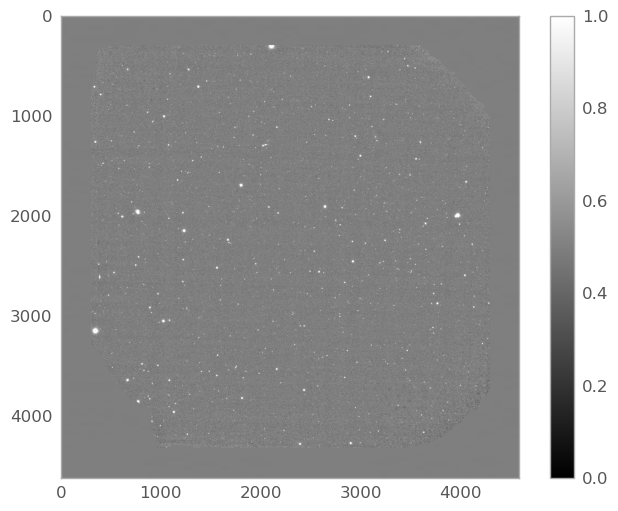

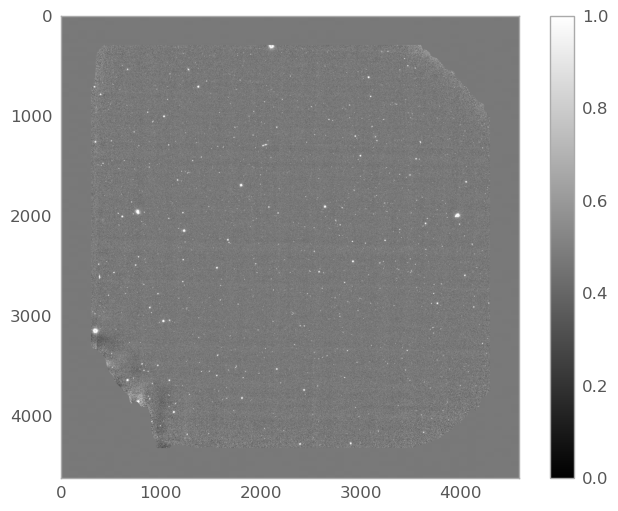

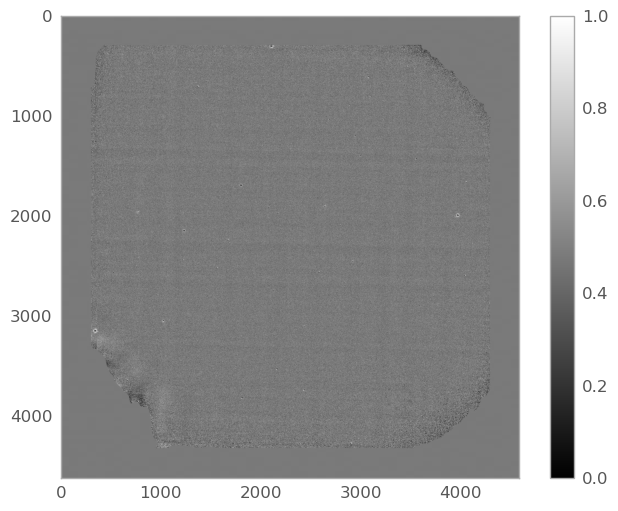

/mnt/photometry/AT2025syx/field8448-2025-07-12/J/stack/coadd.Open-J.02678702-02678738.C2.fits /mnt/photometry/AT2025syx/field8448-2025-12-13/J/stack/coadd.Open-J.03286750-03286786.C2.aligned.fits /mnt/photometry/AT2025syx/sub_test_1789069461.2746172.sfftdiff.fits
['/mnt/photometry/AT2025syx/field8448-2025-07-12/J/stack/GRB_query_thresh.reg']
circle(353.1505671, -28.5251264, 1.0") # color=cyan width=2 text={Query Thresh}
Region: CircleSkyRegion
center: <SkyCoord (ICRS): (ra, dec) in deg
    (353.1505671, -28.5251264)>
radius: 1.0 arcsec red
made cutout:  /mnt/photometry/AT2025syx/field8448-2025-07-12/J/stack/GRB_sci_Cutout.png


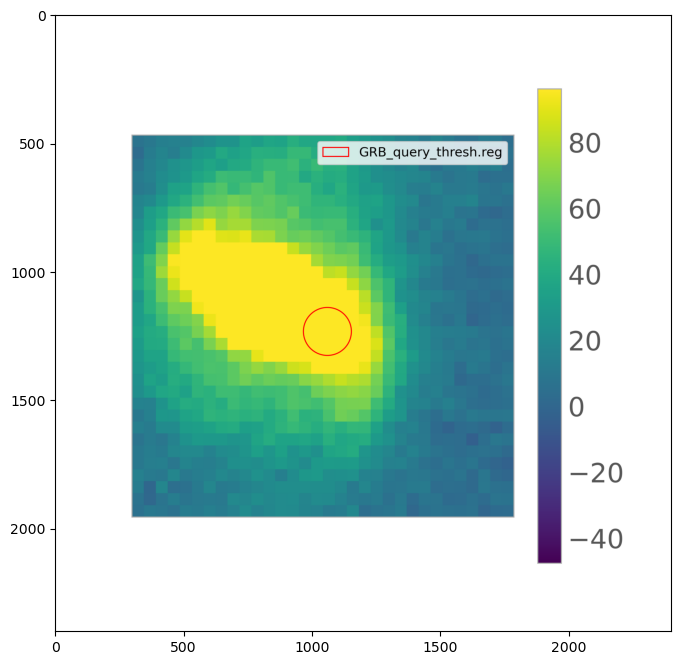

['/mnt/photometry/AT2025syx/field8448-2025-12-13/J/stack/GRB_query_thresh.reg']
circle(353.1505671, -28.5251264, 1.0") # color=cyan width=2 text={Query Thresh}
Region: CircleSkyRegion
center: <SkyCoord (ICRS): (ra, dec) in deg
    (353.1505671, -28.5251264)>
radius: 1.0 arcsec red
made cutout:  /mnt/photometry/AT2025syx/field8448-2025-12-13/J/stack/GRB_ref_Cutout.png


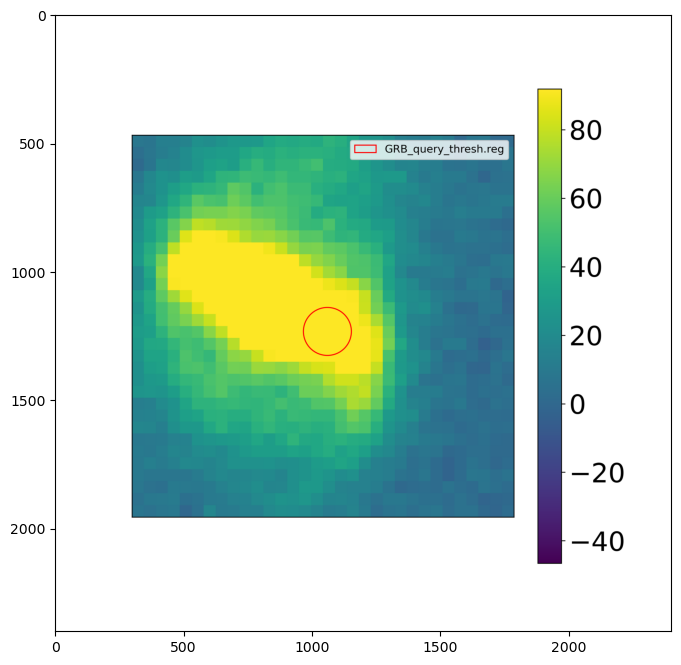

[]
made cutout:  /mnt/photometry/AT2025syx/GRB_diff_Cutout.png


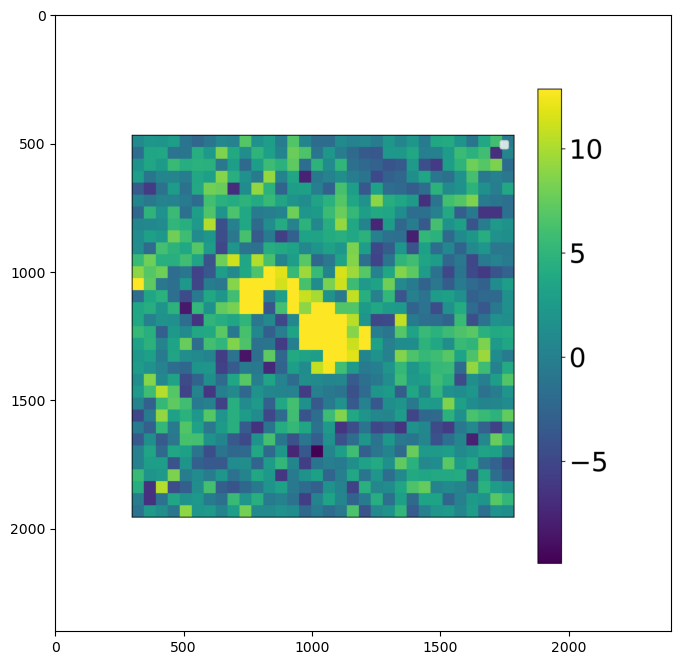

('GRB_diff_Cutout', 'GRB_diff_query_thresh.reg')

In [7]:
ra, dec = sfft_util.get_ra_dec(FITS_SCI)

util.display(FITS_mSCI)
util.display(FITS_mREF)
util.display(FITS_DIFF)

print(FITS_SCI, FITS_REF, FITS_DIFF)

# util.display(sci_weight_path)
# util.display(ref_weight_path)

util.make_cutout(FITS_mSCI, ra, dec, png=True, display_file=True, name_ext="sci")
util.make_cutout(FITS_mREF, ra, dec, png=True, display_file=True, name_ext="ref")
util.make_cutout(FITS_DIFF, ra, dec, png=True, display_file=True, name_ext="diff")


#### Source Analysis

dict_keys(['PixA_REF', 'PixA_SCI', 'REF-SAT-Mask', 'SCI-SAT-Mask', 'Union-NaN-Mask', 'SATLEVEL_REF', 'SATLEVEL_SCI', 'SExCatalog-SubSource', 'SFFT-LabelMap', 'Active-Mask', 'PixA_mREF', 'PixA_mSCI', 'MAG_OFFSET', 'FWHM_REF', 'FWHM_SCI'])
SATLEVEL_REF : 65536.60429247
SATLEVEL_SCI : 65535.39533529
MAG_OFFSET : -0.061970109769202295
FWHM_REF : 2.4202974420641126
FWHM_SCI : 3.21610262717184

REF RMS: 1.7194417925834655
SCI RMS: 1.6798347809314726
dif should be: 2.4038146703333285
DIFF RMS: 1.9263984335053361
Running sextractor on img to initially find sources...
Executing command: sex sub_test_1789069461.2746172.sfftdiff.fits -c /home/alex/.prime/configs/sex2_aggr.config -CATALOG_NAME sub_test_1789069461.2746172.sfftdiff.fits.cat -PARAMETERS_NAME /home/alex/.prime/configs/tempsource.param
wrote to  sub_test_1789069461.2746172.sfftdiff.fits.cat
13625 raw sources
13625 ztf cuts sources


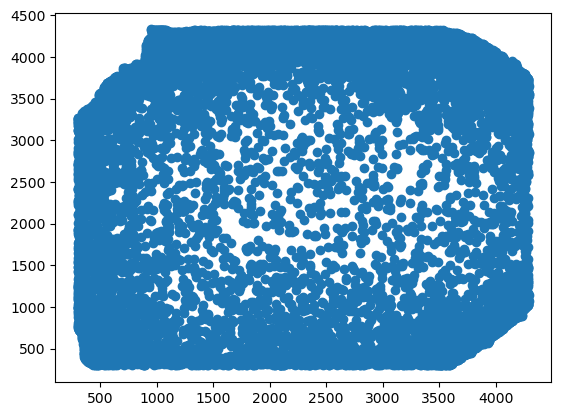

AttributeError: 'DataFrame' object has no attribute 'colnames'

In [8]:

rms_ref, rms_sci, rms_diff_predicted, rms_diff = sfft_util.get_diff_stats(SFFTPrepDict, PixA_DIFF)

diff_cat = sfft_util.source_extract(FITS_DIFF)
print(len(diff_cat), "raw sources")
good_ztf_sources = sfft_util.ztf_cuts(diff_cat, PixA_DIFF)
print(len(good_ztf_sources), "ztf cuts sources")

plt.scatter(good_ztf_sources['X_IMAGE'], good_ztf_sources['Y_IMAGE'])
plt.show()

source_savename, source_threshname, closest_ra, closest_dec = sfft_util.closest_source(good_ztf_sources, FITS_DIFF, ra, dec)

# print(np.shape(PixA_DIFF))
# print(len(good_ztf_sources), "sources")
# print(ra, dec)

# distance = ((ra-closest_ra)**2 + (dec-closest_dec)**2)**(1/2)
# distance = round(distance*3600,3)


#### Boguses and additional analysis

In [ ]:

bogus_coords = {"AT2024acdq":[52.43301900536419, -32.098768098394586], 
                "AT2025syx":[352.97641781649025, -28.65682938159262],
                "AT2025wdq":[36.21625305425166, -24.817318526608844],
                "AT2025foi":[193.42981039864407, -15.619197073527094],
               }

bog_ra = bogus_coords[id_tag][0]
bog_dec = bogus_coords[id_tag][1]

print("bogus ra, bogus dec", bog_ra, bog_dec)
threshold = .01 # 60 / 3600

util.make_cutout(FITS_DIFF, bog_ra, bog_dec, png=True, display_file=True)

for i in range(len(good_ztf_sources)):
   
    source = good_ztf_sources.iloc[i]
    source_ra = source['ALPHA_J2000']
    source_dec = source['DELTA_J2000']
    # if abs(source_ra-ra) < threshold and abs(source_dec-dec) < threshold:
    print("Found source!")
    print("soruce ra, dec:", source_ra, source_dec)
    # print(source)
    util.make_cutout(FITS_DIFF, source_ra, source_dec, png=True, display_file=True)



In [ ]:

sources = sfft_util.source_extract(FITS_DIFF)


#TODO add a check here to see if source ra, dec in sources 
good_ztf_sources = sfft_util.ztf_cuts(sources, PixA_DIFF)

print(np.shape(PixA_DIFF))
print(len(good_ztf_sources), "sources")
print(ra, dec)




In [ ]:
diff_savename, diff_threshname = util.make_cutout(FITS_SCI, ra, dec, png=True, display_file=True, name_ext="sci")
diff_savename, diff_threshname = util.make_cutout(FITS_REF, ra, dec, png=True, display_file=True, name_ext="ref")
diff_savename, diff_threshname = util.make_cutout(FITS_DIFF, ra, dec, png=True, display_file=True, name_ext="diff")




In [ ]:
source_savename, source_threshname, closest_ra, closest_dec = sfft_util.closest_source(good_ztf_sources, FITS_DIFF, ra, dec)

distance = ((ra-closest_ra)**2 + (dec-closest_dec)**2)**(1/2)
distance = round(distance*3600,3)

threshold = 60 / 3600
for i in range(len(good_ztf_sources)):
   
    source = good_ztf_sources.iloc[i]
    source_ra = source['ALPHA_J2000']
    source_dec = source['DELTA_J2000']
    if abs(source_ra-ra) < threshold and abs(source_dec-dec) < threshold:
        print("Found source!")
        print(source_ra, source_dec)
        print(source)
		  
    
print("distance to closest extracted source:", distance)

util.display(f"{source_savename}.png", source_savename)